In [1]:
#Importando as bibliotecas

import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import linregress


In [2]:
#Definindo a variável "arquivo" pelo nome da planilha.

arquivo='lanches_menu.xlsx'


In [3]:
#lendo a planilha no Python. Escolhemos o nome df para armazenar.

df=pd.read_excel(arquivo)

In [4]:
#Vizualindo as 5 primeiras observações do dataframe df
df.head()

,Menu Category,Menu Items,peso,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_carboidratos_g,total_acucar,Added Sugars(g),Sodium
0,Regular Menu,McVeggie™ Burger,168 g,40205,1024,1383,534,16,249,5654,79,449,70613.0
1,Regular Menu,McAloo Tikki Burger®,146 g,33952,85,1131,427,2,147,5027,705,407,54534.0
2,Regular Menu,McSpicy™ Paneer Burger,199 g,65276,2029,3945,1712,18,2185,5233,835,527,107458.0
3,Regular Menu,Spicy Paneer Wrap,250 g,67468,2096,391,1973,26,4093,5927,35,108,108746.0
4,Regular Menu,American Veg Burger,177 g,51217,153,2345,1051,17,2524,5696,785,476,105124.0


#Cálculo do Coeficiente de Correlação Linear de Pearson, Gráfico de Dispersão, Reta de Regressão e cálculo do Coeficiente de Determinação.

##Pela Biblioteca Scipy.stats

In [5]:
df=df.dropna()

In [6]:
#Definindo a variável independente x e a variável dependente y
x=df.energia.values
y=df.Sodium.values


In [8]:
#Calculando os parâmetros da reta de regressão linear
res = stats.linregress(x, y)


In [14]:
#Exibindo os resultados do comando anterior.
#slope= coeficiente angular da reta de regressão linear
#intercept = coeficiente linear da reta de regressão linear
#rvalue= valor do coeficiente de correlação linear

res.rvalue

np.float64(0.7154380780975583)

In [10]:
#Caso queira calcular um parâmetro específico basta usar a estrutura res.nome_do_parâmetro.
#Por exemplo:
res.slope

np.float64(1.7945084611470434)

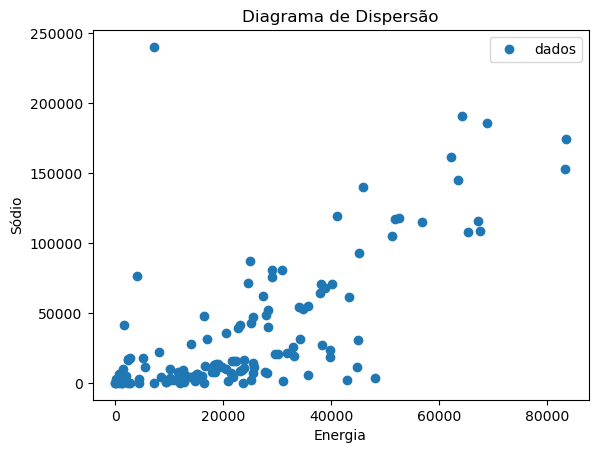

In [15]:
#Plotando o diagrama de dispersão de x por y.
plt.plot(x, y, 'o',label="dados")
plt.title('Diagrama de Dispersão')
plt.xlabel("Energia")
plt.ylabel('Sódio')
plt.legend()
plt.show()

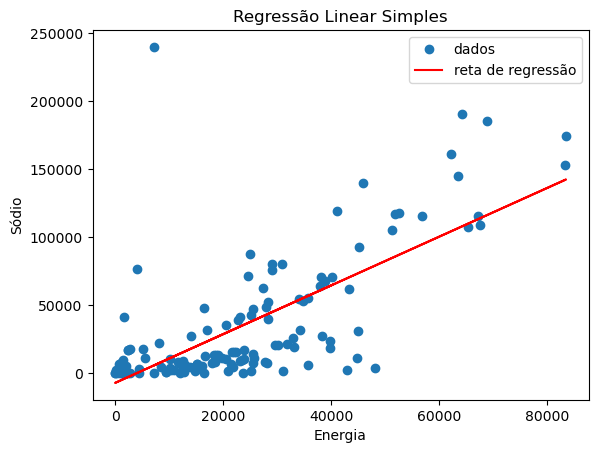

In [16]:
#Plotando o diagrama de dispersão de x por y e a reta de regressão linear
plt.plot(x, y, 'o', label='dados')
plt.plot(x, res.slope*x + res.intercept, 'r', label='reta de regressão')
plt.title('Regressão Linear Simples')
plt.xlabel("Energia")
plt.ylabel('Sódio')
plt.legend()
plt.show()

AJUSTANDO VALORES DOS EIXOS


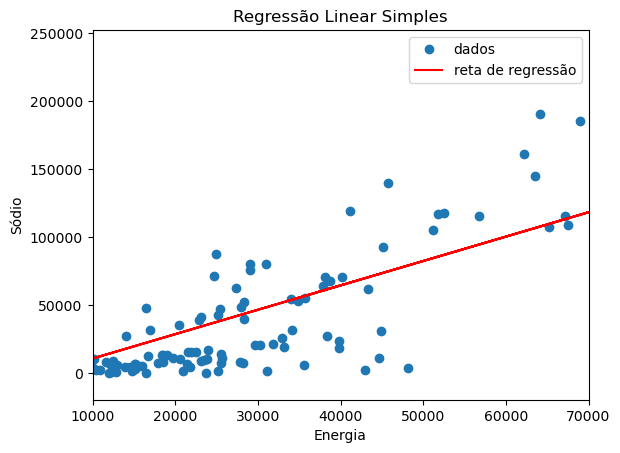

In [20]:
#Para limitar os valores do eixo x, basta usar o comando plt.xlim(Menor_valor,Maior_valor)

plt.plot(x, y, 'o', label='dados')
plt.plot(x, res.slope*x + res.intercept, 'r', label='reta de regressão')
plt.title('Regressão Linear Simples')
plt.xlabel("Energia")
plt.ylabel('Sódio')
plt.legend()
plt.xlim(10000,70000)
plt.show()

In [41]:
#Exibindo os valores dos coeficientes e a equação da reta de regressão linear:
print(f"Coeficiente de correlação r = {res.rvalue:.4f}")
print( f"Coeficiente linear =  {res.intercept:.4f}")
print( f"Coeficiente angular =  {res.slope:.4f}")
print(f"Reta de regressão linear y = {res.slope:.4f}",f"*x + {res.intercept:.4f}" )
print(f"Coeficiente de determinação r^2 = {res.rvalue**2:.4f}")

Coeficiente de correlação r = 0.7154
Coeficiente linear =  -7327.3437
Coeficiente angular =  1.7945
Reta de regressão linear y = 1.7945 *x + -7327.3437
Coeficiente de determinação r^2 = 0.5119


# **`CONTEÚDO EXTRA`**





O contéudo a seguir foi inserido no notebook para mostrar os comandos quando queremos estudar a correlação entre várias váriáveis simultaneamente.

# Matriz dos coeficientes de correlação - método corr() do Pandas. Biblioteca Seaborn

### Quando o Data Set estudado tem mais de duas variáveis quantitativas, podemos estudar o coeficiente de correlação de forma simultânea de todas as variáveis quantitativas.

In [44]:
#Apresenta a matriz de correlação linear duas a duas das variáveis quantitativas do Data Set.
df.corr(numeric_only=True)

,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_casrboidartos_g,total_acucar,Added Sugars(g),Sodium
energia,1.000000,0.686630,0.858027,0.723535,0.087596,0.425268,0.664773,0.098769,0.063146,0.715438
proteina,0.686630,1.000000,0.735125,0.649004,0.203772,0.574137,0.291151,-0.228475,-0.252360,0.798268
gordura_total,0.858027,0.735125,1.000000,0.701947,0.169945,0.466315,0.392868,-0.126245,-0.179823,0.749749
gordura_saturada,0.723535,0.649004,0.701947,1.000000,-0.075415,0.381333,0.410651,-0.060332,-0.149460,0.568067
gordura_trans,0.087596,0.203772,0.169945,-0.075415,1.000000,-0.039329,-0.105166,-0.071756,-0.059784,0.158081
colesterol,0.425268,0.574137,0.466315,0.381333,-0.039329,1.000000,0.109307,-0.151042,-0.174167,0.453910
total_casrboidartos_g,0.664773,0.291151,0.392868,0.410651,-0.105166,0.109307,1.000000,0.505943,0.477487,0.386328
total_acucar,0.098769,-0.228475,-0.126245,-0.060332,-0.071756,-0.151042,0.505943,1.000000,0.813130,-0.240187
Added Sugars(g),0.063146,-0.252360,-0.179823,-0.149460,-0.059784,-0.174167,0.477487,0.813130,1.000000,-0.219916
Sodium,0.715438,0.798268,0.749749,0.568067,0.158081,0.453910,0.386328,-0.240187,-0.219916,1.000000


# Diagramas de dispersão simultâneos - sns.pairplot()

É possível plotar os diagramas de dispersão das variáveis quantitativas duas a duas simultaneamente.

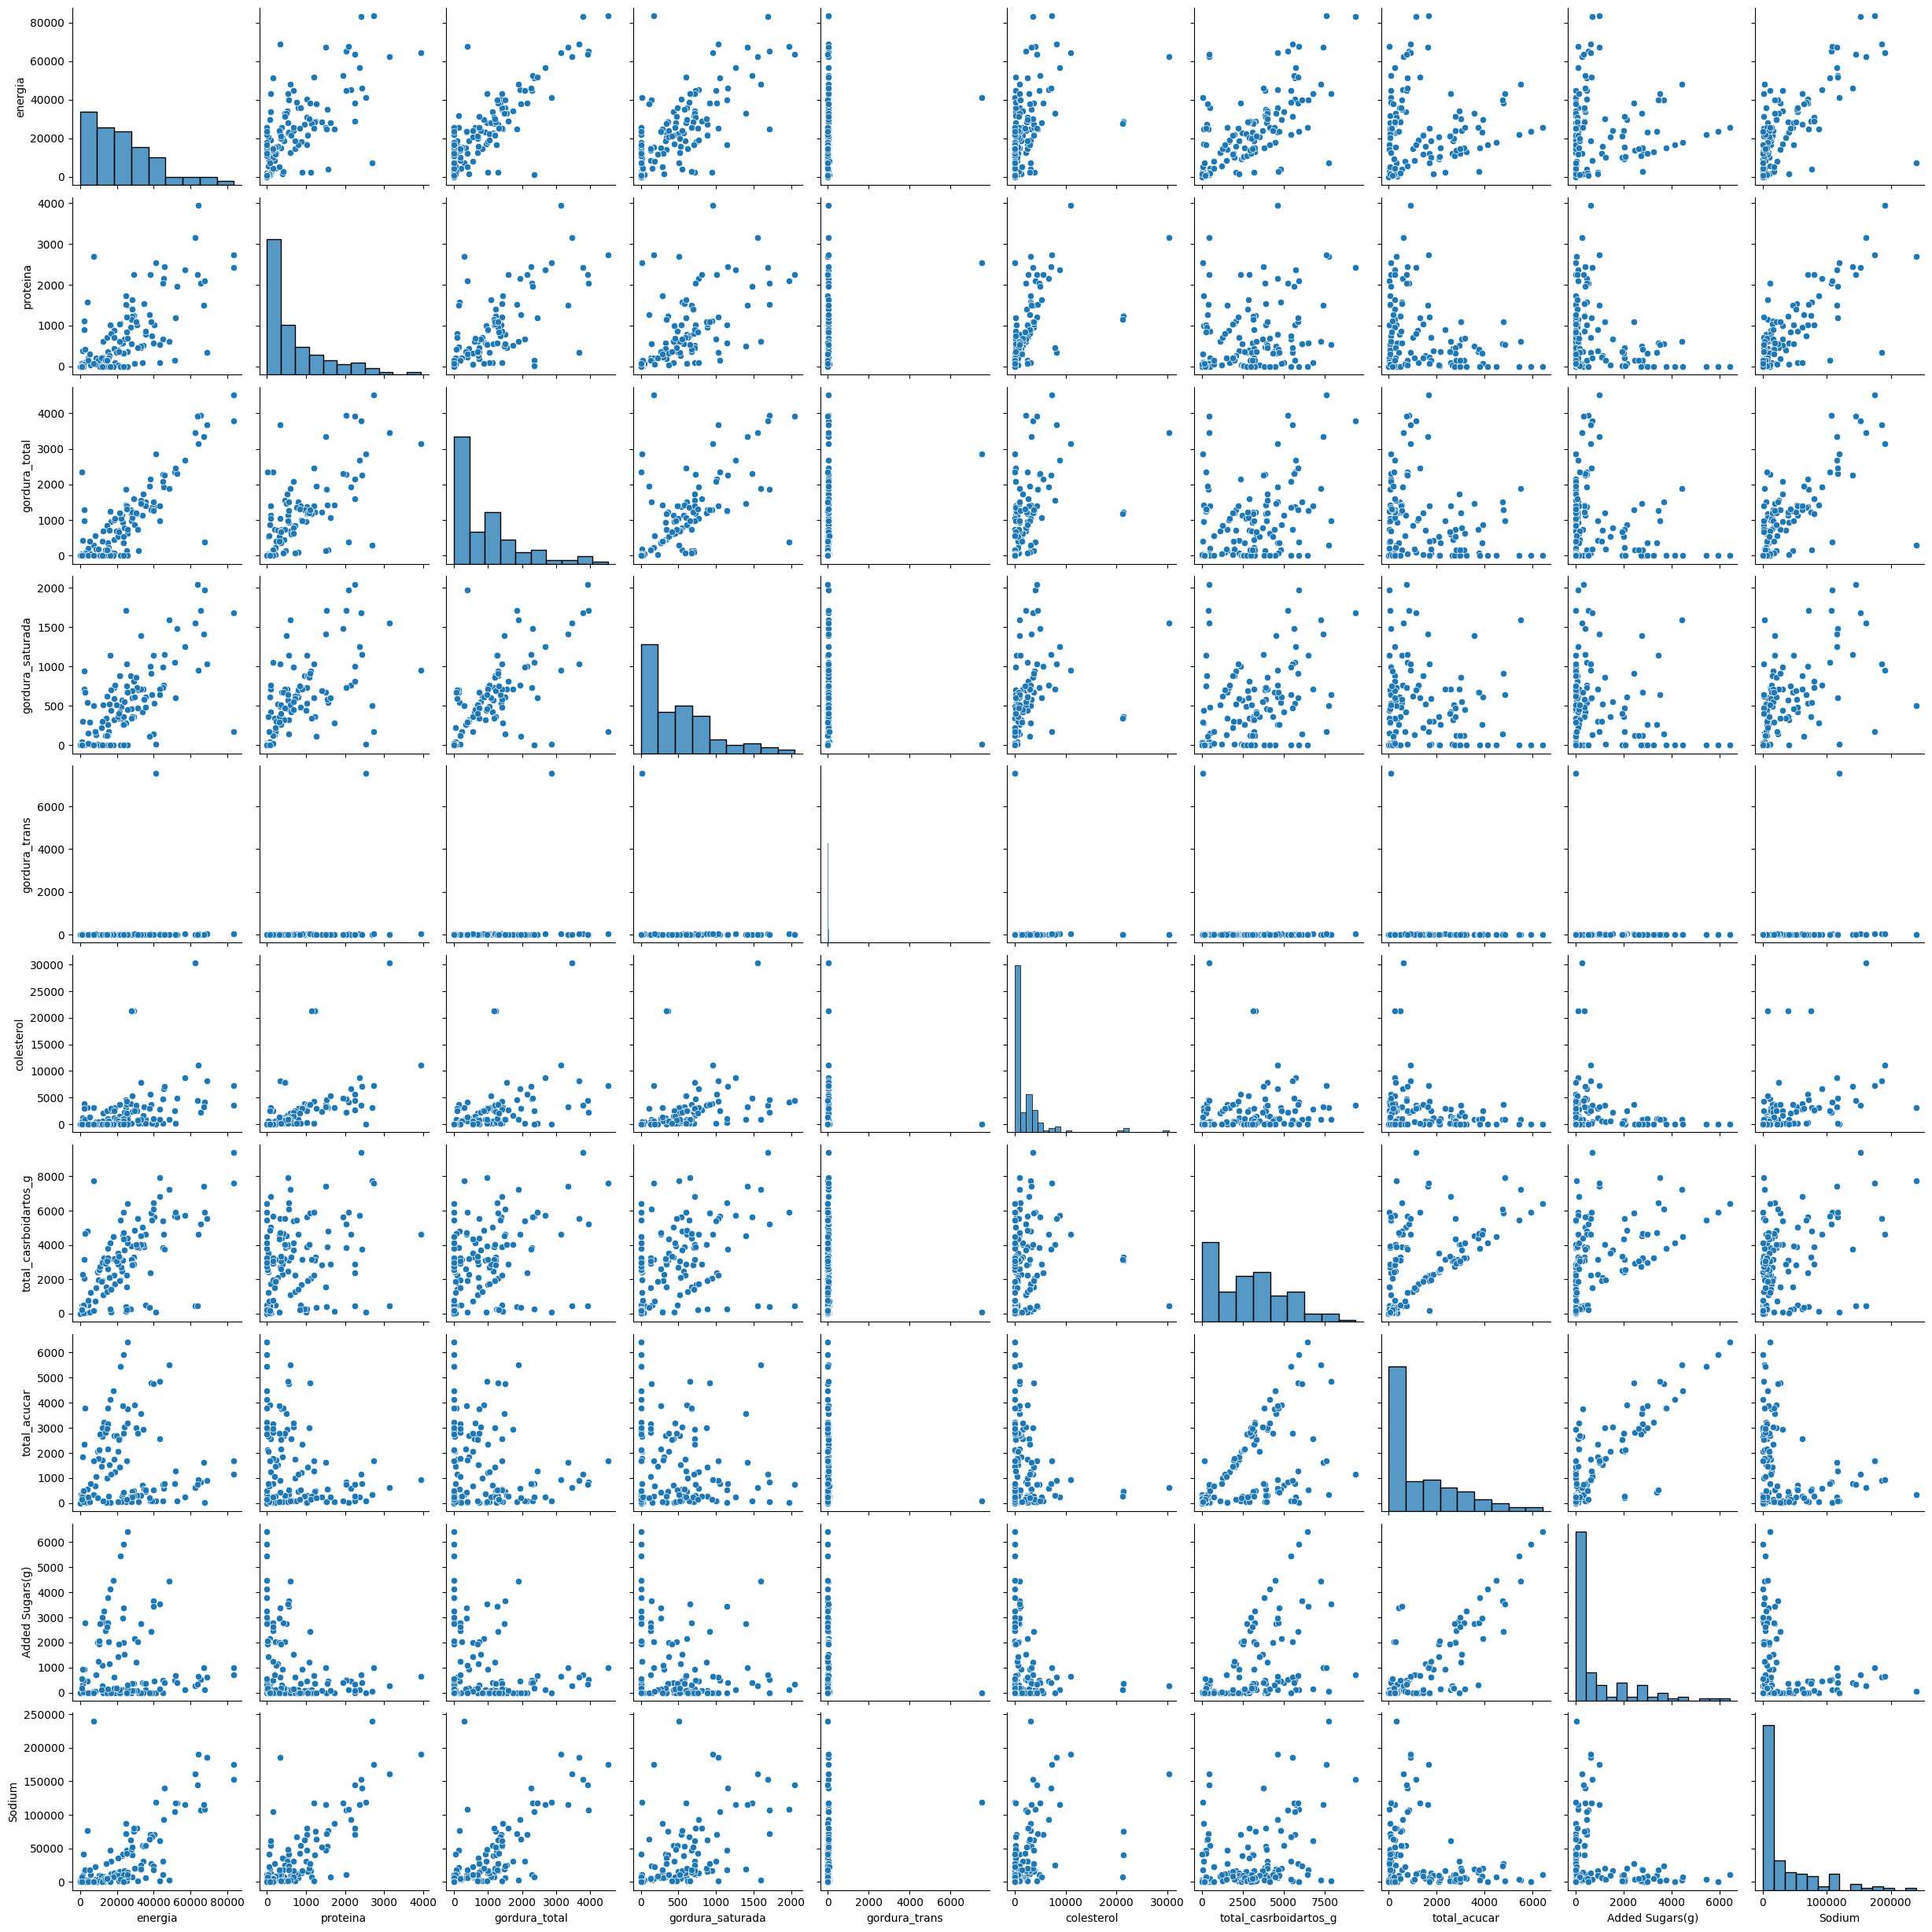

In [48]:
sns.pairplot(data=df)
plt.show()

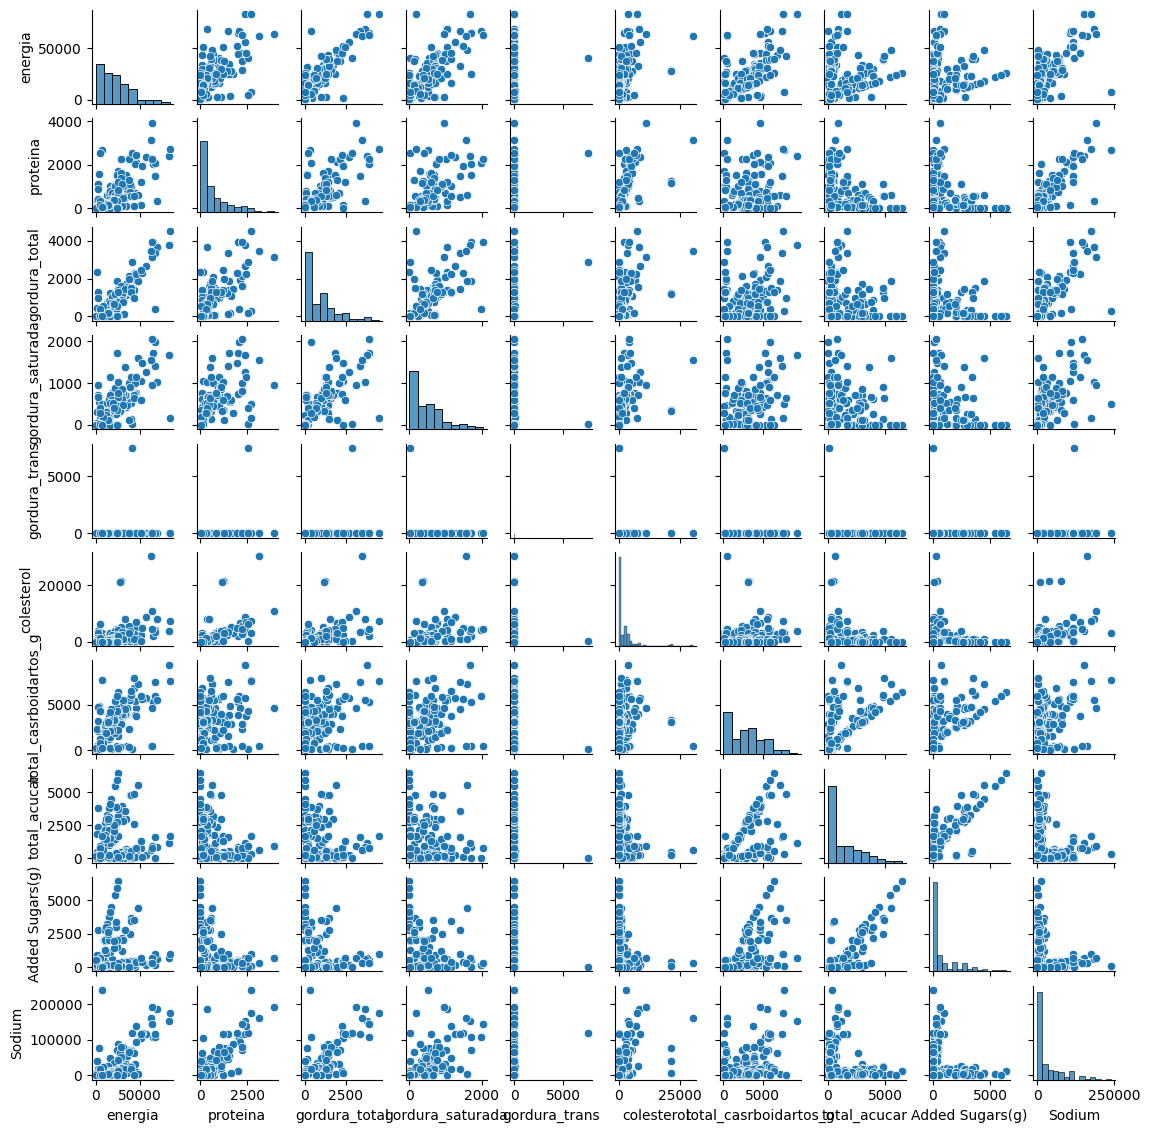

In [46]:
# Ajustando a altura para adequar o gráfico à tela.
sns.pairplot(data=df,height=1.15)
plt.show()

# Heatmap (mapa de calor) dos coeficientes de correlação

Podemos contruir uma tabela de escala de cores dependendo do valor do coeficiente de correlação r.


In [51]:
#Matriz de correlação do Data Set
matrizcorrelacao = df.corr(numeric_only=True)
matrizcorrelacao

,energia,proteina,gordura_total,gordura_saturada,gordura_trans,colesterol,total_casrboidartos_g,total_acucar,Added Sugars(g),Sodium
energia,1.000000,0.686630,0.858027,0.723535,0.087596,0.425268,0.664773,0.098769,0.063146,0.715438
proteina,0.686630,1.000000,0.735125,0.649004,0.203772,0.574137,0.291151,-0.228475,-0.252360,0.798268
gordura_total,0.858027,0.735125,1.000000,0.701947,0.169945,0.466315,0.392868,-0.126245,-0.179823,0.749749
gordura_saturada,0.723535,0.649004,0.701947,1.000000,-0.075415,0.381333,0.410651,-0.060332,-0.149460,0.568067
gordura_trans,0.087596,0.203772,0.169945,-0.075415,1.000000,-0.039329,-0.105166,-0.071756,-0.059784,0.158081
colesterol,0.425268,0.574137,0.466315,0.381333,-0.039329,1.000000,0.109307,-0.151042,-0.174167,0.453910
total_casrboidartos_g,0.664773,0.291151,0.392868,0.410651,-0.105166,0.109307,1.000000,0.505943,0.477487,0.386328
total_acucar,0.098769,-0.228475,-0.126245,-0.060332,-0.071756,-0.151042,0.505943,1.000000,0.813130,-0.240187
Added Sugars(g),0.063146,-0.252360,-0.179823,-0.149460,-0.059784,-0.174167,0.477487,0.813130,1.000000,-0.219916
Sodium,0.715438,0.798268,0.749749,0.568067,0.158081,0.453910,0.386328,-0.240187,-0.219916,1.000000


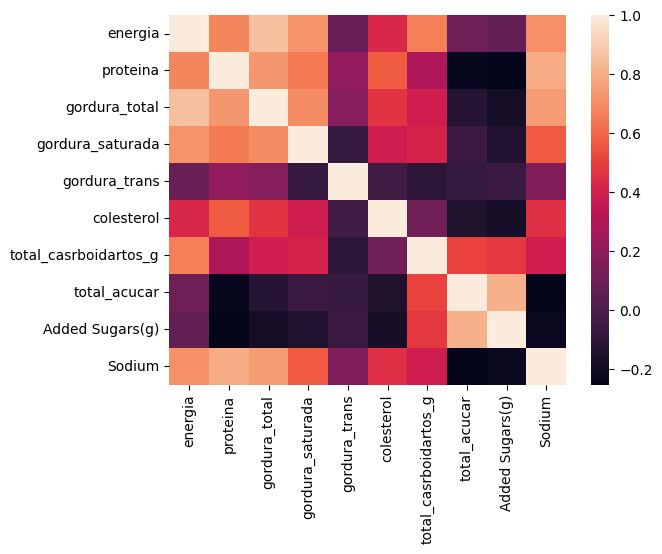

In [52]:
# Mapa de Calor (heatmap) básico
sns.heatmap(matrizcorrelacao)
plt.show()

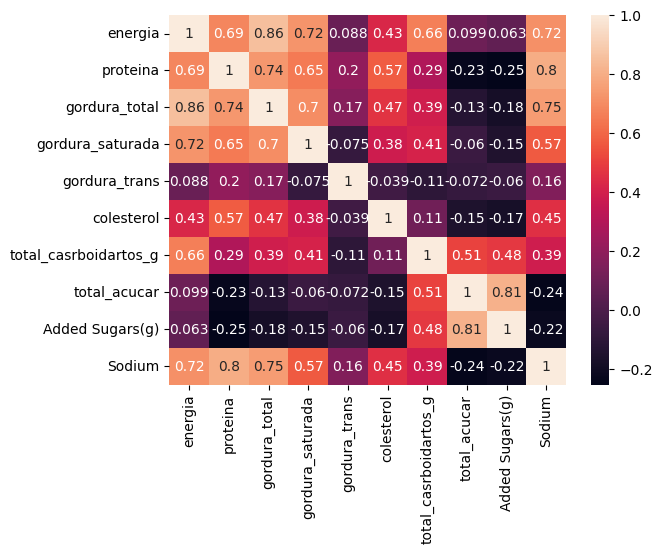

In [53]:
# Heatmap exibindo os valores de r
sns.heatmap(matrizcorrelacao, annot = True)
plt.show()

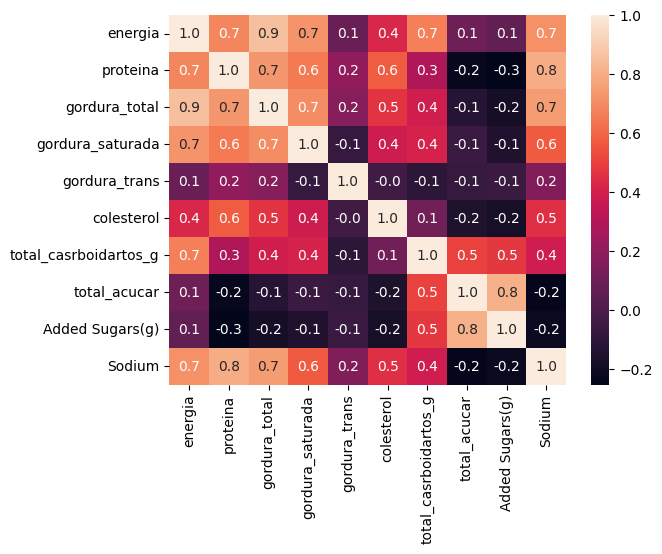

In [54]:
# Alterar o número de casas decimais de heatmap
sns.heatmap(matrizcorrelacao, annot = True, fmt=".1f")
plt.show()

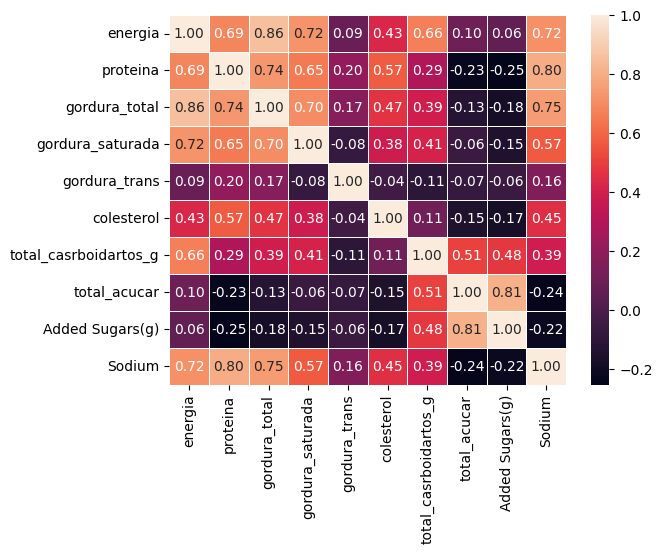

In [55]:
# Ajustar a espessura/largura das linhas do heatmap
sns.heatmap(matrizcorrelacao, annot = True, fmt=".2f", linewidths=0.6)
plt.show()

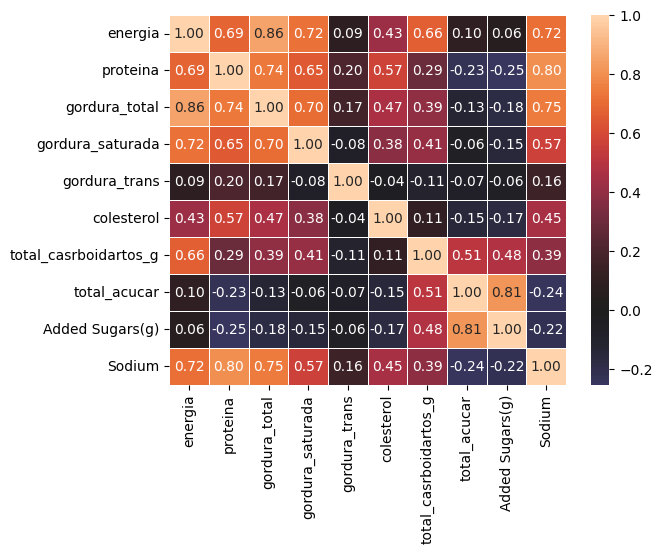

In [56]:
# Posicionando o centro no zero na barra de referência do heatmap
# ATENÇÃO: se você não posicionar em zero, a função vai centralizar no ponto
# médio dos dados disponíveis, o que pode distorcer a interpretação
sns.heatmap(matrizcorrelacao, annot = True, fmt=".2f", linewidths=0.6, center=0)
plt.show()

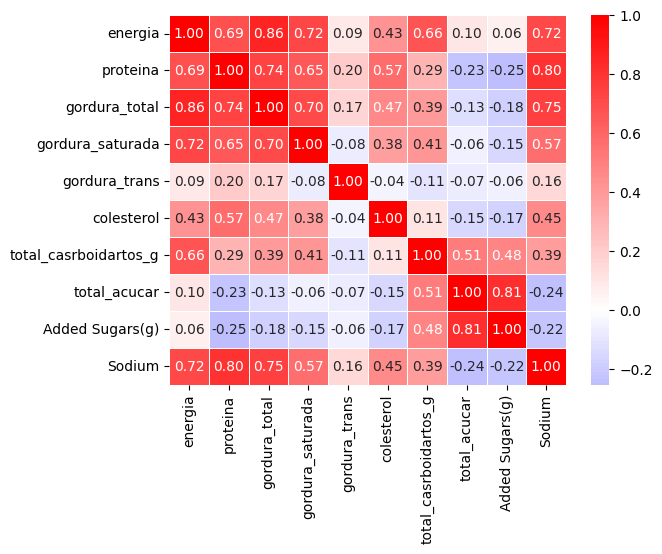

In [57]:
# Escolhendo heatmap variando de azul para vermelho (cmap = "bwr")
# para ver lista de cores pesquise por "choosing colormaps in matplotlib"
sns.heatmap(matrizcorrelacao, annot = True, fmt=".2f", linewidths=0.6, center = 0, cmap= "bwr")
plt.show()

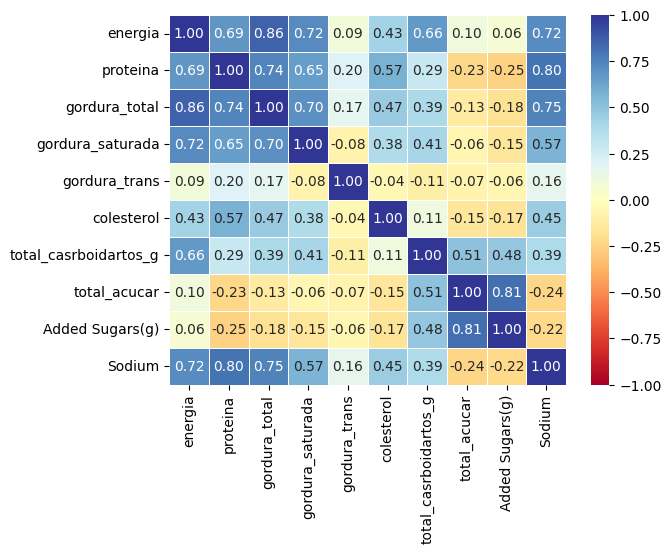

In [58]:
# É uma boa prática, quando possível, estabelecer os valores min e max
# Neste caso, é importante para evitar distorções
sns.heatmap(matrizcorrelacao, annot = True, fmt=".2f", linewidths=0.6, center = 0, vmin=-1, vmax=1, cmap= "RdYlBu")
plt.show()

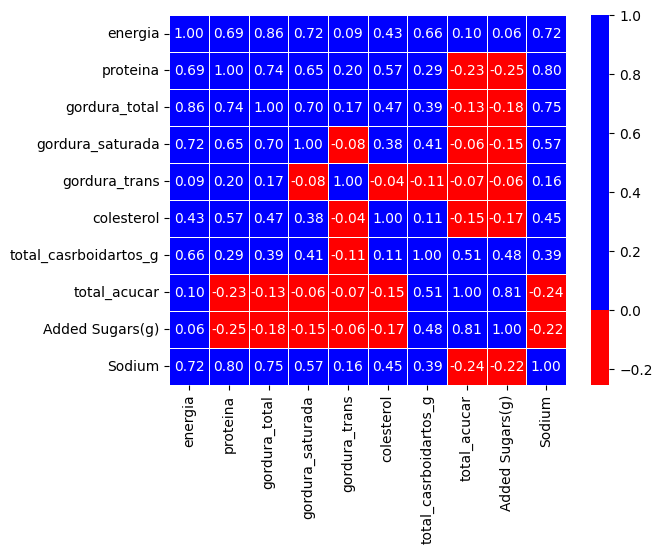

In [59]:
# Separando positivos e negativos (abaixo e acima do centro)
# Basta passar uma lista de cores
sns.heatmap(matrizcorrelacao, annot = True, fmt=".2f", linewidths=0.6, center = 0, cmap=["Red", "Blue"])
plt.show()